In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
import os

# Suppress TensorFlow interactive logging
tf.keras.utils.disable_interactive_logging()

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
print("--- Part 1: Loading and Preprocessing the MNIST Dataset ---")

# Load MNIST dataset
(x_train, _), (_, _) = mnist.load_data()

# Reshape to (number of images, 28, 28, 1)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype("float32")

# Normalize pixel values from [0, 255] to [-1, 1]
x_train = (x_train - 127.5) / 127.5

print("Normalized training data shape:", x_train.shape)
print("Example normalized pixel value:", x_train[0, 0, 0, 0])


--- Part 1: Loading and Preprocessing the MNIST Dataset ---
Normalized training data shape: (60000, 28, 28, 1)
Example normalized pixel value: -1.0


In [3]:
latent_dim = 100
batch_size = 256
EPOCHS = 200
num_examples_to_generate = 16

print("Latent dimension:", latent_dim)
print("Batch size:", batch_size)
print("Epochs:", EPOCHS)


Latent dimension: 100
Batch size: 256
Epochs: 200


In [5]:
# Cell 4 - Build the Generator

print("--- Building Generator ---")

def build_generator():
    model = keras.Sequential(name="generator")

    # Input: 100-dimensional random noise
    model.add(
        layers.Input(shape=(latent_dim,))
    )

    # 100 -> 7 x 7 x 256
    model.add(
        layers.Dense(
            7 * 7 * 256,
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Reshape to 7 x 7 x 256
    model.add(
        layers.Reshape((7, 7, 256))
    )

    # 7 x 7 x 256 -> 7 x 7 x 128
    model.add(
        layers.Conv2DTranspose(
            128,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 7 x 7 x 128 -> 14 x 14 x 64
    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 14 x 14 x 64 -> 28 x 28 x 1
    model.add(
        layers.Conv2DTranspose(
            1,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False,
            activation="tanh"
        )
    )

    return model


# Create generator
generator = build_generator()

# Display model architecture
print("\n--- Generator Model Summary ---")
generator.summary()


--- Building Generator ---

--- Generator Model Summary ---


In [6]:
# Generate random noise
noise = tf.random.normal([1, latent_dim])

# Generate one image
generated_image = generator(noise, training=False)

print("Generated image shape:", generated_image.shape)


Generated image shape: (1, 28, 28, 1)


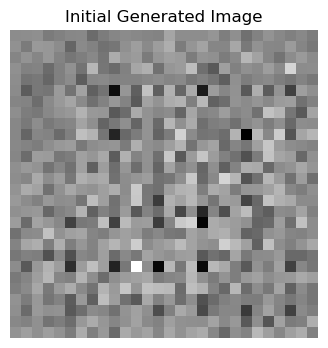

In [7]:
plt.figure(figsize=(4, 4))

plt.imshow(
    generated_image[0, :, :, 0],
    cmap="gray"
)

plt.axis("off")
plt.title("Initial Generated Image")
plt.show()


In [9]:
# Cell 7 - Build the Discriminator

print("--- Building Discriminator ---")

def build_discriminator():
    model = keras.Sequential(name="discriminator")

    # Input layer
    model.add(
        layers.Input(shape=(28, 28, 1))
    )

    # 28 x 28 x 1 -> 14 x 14 x 64
    model.add(
        layers.Conv2D(
            64,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same"
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # 14 x 14 x 64 -> 7 x 7 x 128
    model.add(
        layers.Conv2D(
            128,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same"
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Flatten
    model.add(layers.Flatten())

    # Output: probability that image is real
    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    return model


# Create discriminator
discriminator = build_discriminator()

print("\n--- Discriminator Model Summary ---")
discriminator.summary()


--- Building Discriminator ---

--- Discriminator Model Summary ---


In [10]:
decision = discriminator(generated_image)

print("Discriminator output:", decision.numpy())


Discriminator output: [[0.50008905]]


In [11]:
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=False)


def discriminator_loss(real_output, fake_output):
    # Real images should be classified as 1
    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    # Fake images should be classified as 0
    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss


def generator_loss(fake_output):
    # Generator wants fake images to be classified as real
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


print("Loss functions created.")


Loss functions created.


In [12]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)

print("Optimizers created.")


Optimizers created.


In [13]:
@tf.function
def train_step(images):
    # Generate random noise
    noise = tf.random.normal(
        [batch_size, latent_dim]
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generate fake images
        generated_images = generator(
            noise,
            training=True
        )

        # Discriminator predictions
        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update generator
    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    # Update discriminator
    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss


In [14]:
train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_train)
    .shuffle(x_train.shape[0])
    .batch(batch_size, drop_remainder=True)
)

print("Dataset prepared.")
print("Batch size:", batch_size)


Dataset prepared.
Batch size: 256


In [15]:
seed = tf.random.normal(
    [num_examples_to_generate, latent_dim]
)

print("Seed shape:", seed.shape)


Seed shape: (16, 100)


In [16]:
def train(dataset, epochs):

    print("\n--- Beginning GAN Training ---")

    for epoch in range(epochs):

        gen_loss_list = []
        disc_loss_list = []

        for image_batch in dataset:

            gen_loss, disc_loss = train_step(
                image_batch
            )

            gen_loss_list.append(
                gen_loss.numpy()
            )

            disc_loss_list.append(
                disc_loss.numpy()
            )

        # Calculate average losses
        avg_gen_loss = np.mean(gen_loss_list)
        avg_disc_loss = np.mean(disc_loss_list)

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Generator Loss: {avg_gen_loss:.4f}, "
            f"Discriminator Loss: {avg_disc_loss:.4f}"
        )

        # Generate images every 20 epochs
        if (epoch + 1) % 20 == 0:

            generate_and_save_images(
                generator,
                epoch + 1,
                seed
            )

    print("\n--- Training Complete ---")

    # Generate final images
    generate_and_save_images(
        generator,
        epochs,
        seed
    )


In [ ]:
train(
    train_dataset,
    EPOCHS
)



--- Beginning GAN Training ---


In [ ]:
final_noise = tf.random.normal(
    [16, latent_dim]
)

final_images = generator(
    final_noise,
    training=False
)

final_images = (
    final_images * 0.5
) + 0.5

plt.figure(figsize=(6, 6))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        final_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()
